In [15]:
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Partie 2 : Résolution numérique du problème individuel

**Méthodes de résolution.** Le problème étant un LP, on peut utiliser :
- la méthode du simplexe (algorithme de contraintes actives adapté aux LP, Appendice C.3 du cours)
- les méthodes de points intérieurs (barrière logarithmique)

Nous utilisons ici le solveur HiGHS via CasADi, qui implémente ces deux approches


**Question 6**

In [16]:
# on établit les paramètres 
t0 = 23.0
dt = 0.5
N = 48

c_cr = 1.0
c_pl = 3/2

T_m = 18.0
T_M = 30.0
T_in = T_m

h = 0.05
k = 0.01
b = 1/500
P_M = 5000.0

t = np.array([(t0 + i * dt) % 24 for i in range(N + 1)])
T_ext = 4 + 8 * np.exp(-(t - 12)**2 / 40)

def heure_creuse(heure):
    return (0 <= heure < 6) or (12 <= heure < 14)

def occupe(heure):
    return (7 <= heure <= 9) or (18 <= heure <= 23)

c_tarif = np.array([c_cr if is_heure_creuse(t[i]) else c_pl for i in range(N + 1)])
I_occ = [i for i in range(N + 1) if is_occupe(t[i])]

In [17]:
def solve_effacement(c_pl_val):
    c_tarif_loc = np.array([c_cr if is_heure_creuse(t[i]) else c_pl_val for i in range(N + 1)])
#création de "variables symboliques" pou casADi
    P = ca.SX.sym('P', N)
    T = ca.SX.sym('T', N + 1)
#on groupe les deux ( taille 2n+1)
    x = ca.vertcat(P, T)
#fonction coût
    f = dt * ca.dot(c_tarif_loc[:N], P)
#on simplifie l'expression des constantes
    alpha = np.exp(-(k + h) * dt)
    beta = (1 - alpha) / (k + h)

    g = []
    lbg = []
    ubg = []

# condition initiales
    g.append(T[0])
    lbg.append(T_in)
    ubg.append(T_in)

# on calcule la temperaure du batipment à chaque intervalle de temps
    for i in range(N):
        g.append(T[i + 1] - alpha * T[i] - beta * b * P[i])
        lbg.append(beta * h * T_ext[i])
        ubg.append(beta * h * T_ext[i])

# on pose les contraintes de température aux heures d'occupation
    for i in I_occ:
        g.append(T[i])
        lbg.append(T_m)
        ubg.append(T_M)

    g = ca.vertcat(*g)

    lp = {'x': x, 'f': f, 'g': g}
    solver = ca.qpsol('solver', 'highs', lp) #on réecrit le problème avec le nouveau vecteur contrainte g

    lbx = [0.0] * N + [-ca.inf] * (N + 1)
    ubx = [P_M] * N + [ca.inf] * (N + 1)

    sol = solver(lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)

    P_sol = np.array(sol['x'][:N]).flatten()
    T_sol = np.array(sol['x'][N:]).flatten()
    facture = float(sol['f'])

    return P_sol, T_sol, facture

In [18]:
P_opt, T_opt, facture = solve_effacement(c_pl)
print(f"Facture optimale : {facture:.2f}")
print(f"Température min : {T_opt.min():.2f} °C, max : {T_opt.max():.2f} °C")

Facture optimale : 8921.53
Température min : 13.78 °C, max : 22.77 °C


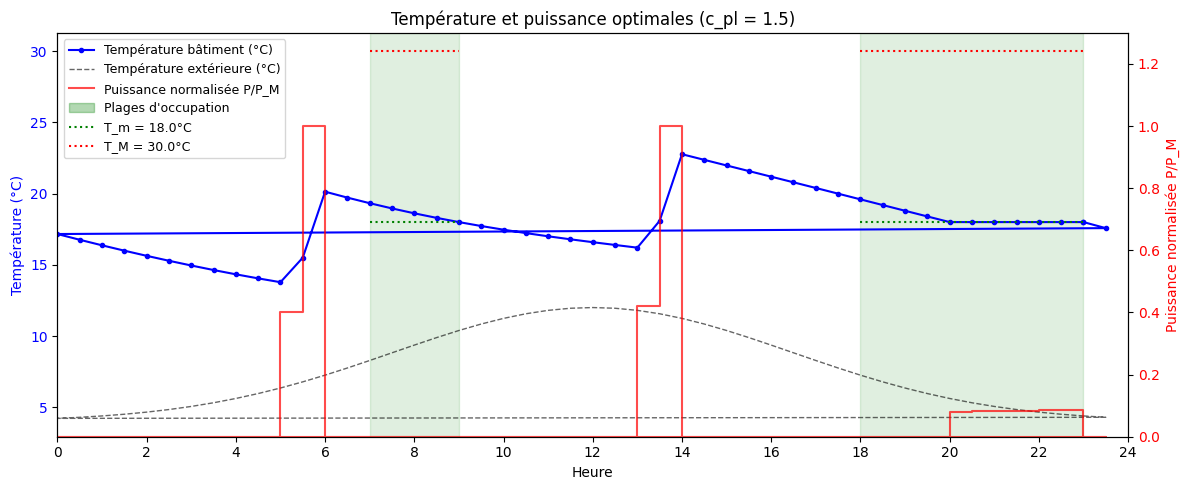

In [19]:
# Graphique (a), température et puissance normalisée ( on divise P par P_M)
fig, ax1 = plt.subplots(figsize=(12, 5))

for ts, te in [(7, 9), (18, 23)]:
    ax1.axvspan(ts, te, alpha=0.12, color='green')

ax1.plot(t, T_opt, 'b-o', markersize=3, label='Température bâtiment (°C)')
ax1.plot(t, T_ext, 'k--', linewidth=1, alpha=0.6, label='Température extérieure (°C)')

for ts, te in [(7, 9), (18, 23)]:
    ax1.hlines(T_m, ts, te, colors='green', linestyles=':', linewidth=1.5)
    ax1.hlines(T_M, ts, te, colors='red', linestyles=':', linewidth=1.5)

ax1.set_xlabel('Heure')
ax1.set_ylabel('Température (°C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(range(0, 25, 2))
ax1.set_xlim(0, 24)

ax2 = ax1.twinx() #on copie l'axe x précédent
P_plot = np.append(P_opt, 0.0)
ax2.step(t, P_plot / P_M, 'r-', where='post', linewidth=1.5, alpha=0.7, label='Puissance normalisée P/P_M')
ax2.set_ylabel('Puissance normalisée P/P_M', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, 1.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
occ_patch = mpatches.Patch(color='green', alpha=0.3, label="Plages d'occupation")
Tm_line = plt.Line2D([0], [0], color='green', linestyle=':', label=f'T_m = {T_m}°C')
TM_line = plt.Line2D([0], [0], color='red', linestyle=':', label=f'T_M = {T_M}°C')
ax1.legend(handles=lines1 + lines2 + [occ_patch, Tm_line, TM_line], loc='upper left', fontsize=9)

plt.title(f'Température et puissance optimales (c_pl = {c_pl})')
plt.tight_layout()# pour eviter que les légendes se recoupent 
# Graphique (b) : puissance normalisée vs tarif corrigéplt.show()

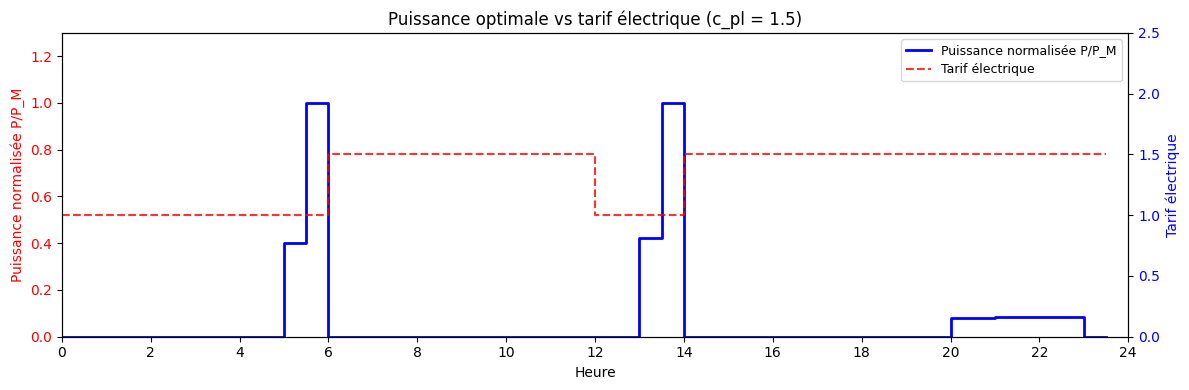

In [24]:
#Graphique B: puissance normalisée vs tarif

sort_idx = np.argsort(t)
t_sorted = t[sort_idx]
P_plot_sorted = P_plot[sort_idx]
c_tarif_sorted = c_tarif[sort_idx]


fig, ax1 = plt.subplots(figsize=(12, 4))

# puissance normalisée 
ax1.step(t_sorted, P_plot_sorted / P_M, 'b-', where='post', linewidth=2, label='Puissance normalisée P/P_M')
ax1.set_ylabel('Puissance normalisée P/P_M', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.set_ylim(0, 1.3)
ax1.set_xticks(range(0, 25, 2))
ax1.set_xlim(0, 24)
ax1.set_xlabel('Heure')

ax2 = ax1.twinx()
# tarif électrique 
ax2.step(t_sorted, c_tarif_sorted, 'r--', where='post', linewidth=1.5, alpha=0.8, label='Tarif électrique')
ax2.set_ylabel('Tarif électrique', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.set_ylim(0, 2.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles=lines1 + lines2, loc='upper right', fontsize=9)

plt.title(f'Puissance optimale vs tarif électrique (c_pl = {c_pl})')
plt.tight_layout()
plt.show()

**Commentaire** L'optimiseur concentre le chauffage pendant les heures creuses (tarif bas), en particulier entre minuit et 6h et entre 12h et 14h. Le bâtiment est préchauffé juste avant les plages d'occupation, ce qui permet de ne presque pas chauffer en heures pleines tout en respectant les contraintes de confort

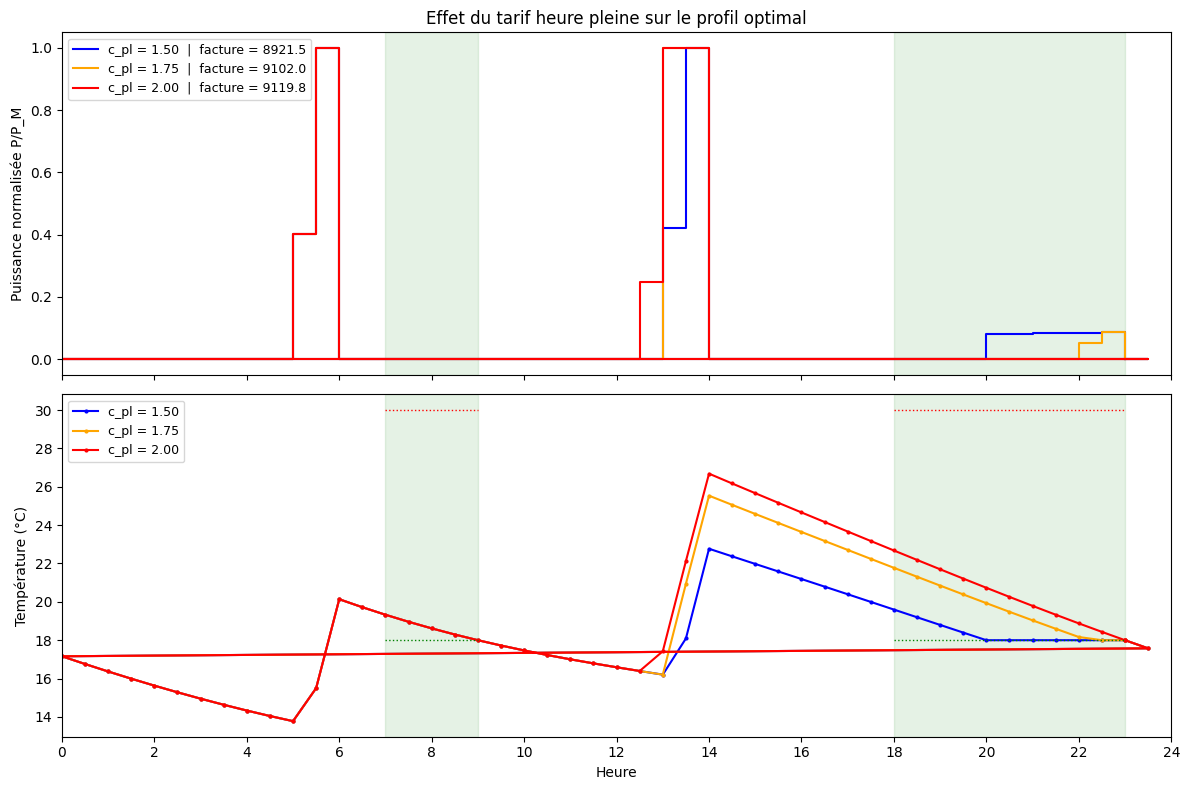

In [25]:
# On compare omparaison pour c_pl = 3/2, 7/4, 2
c_pl_values = [3/2, 7/4, 2]
colors = ['blue', 'orange', 'red']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for c_pl_v, col in zip(c_pl_values, colors):
    P_v, T_v, facture_v = solve_effacement(c_pl_v)
    P_plot_v = np.append(P_v, 0.0)
    axes[0].step(t, P_plot_v / P_M, where='post', color=col, linewidth=1.5,
                 label=f'c_pl = {c_pl_v:.2f}  |  facture = {facture_v:.1f}')
    axes[1].plot(t, T_v, color=col, linewidth=1.5, marker='o', markersize=2,
                 label=f'c_pl = {c_pl_v:.2f}')

for ax in axes:
    for ts, te in [(7, 9), (18, 23)]:
        ax.axvspan(ts, te, alpha=0.1, color='green')
    ax.set_xticks(range(0, 25, 2))
    ax.set_xlim(0, 24)
    ax.legend(fontsize=9)

for ts, te in [(7, 9), (18, 23)]:
    axes[1].hlines(T_m, ts, te, colors='green', linestyles=':', linewidth=1)
    axes[1].hlines(T_M, ts, te, colors='red', linestyles=':', linewidth=1)

axes[0].set_ylabel('Puissance normalisée P/P_M')
axes[1].set_ylabel('Température (°C)')
axes[1].set_xlabel('Heure')
axes[0].set_title('Effet du tarif heure pleine sur le profil optimal')

plt.tight_layout()
plt.show()

**Commentaire.** Plus l'écart entre tarif heure pleine et heure creuse est important, plus le préchauffage nocturne est poussé : pour $c_{pl} = 2$, le chauffage tourne à pleine puissance ($P = P_M$) pendant toute la plage creuse de nuit. La facture diminue avec $c_{pl}$ croissant car l'optimiseur exploite davantage les heures les moins chères. Cela illustre l'**effet incitatif du tarif** : un signal-prix plus fort entraîne un déplacement plus marqué de la consommation vers les heures creuses.